<a href="https://colab.research.google.com/github/willow788/one-model-a-week-keeps-the-fomo-away/blob/main/CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
!pip install keras
from tensorflow.keras import datasets, layers, Model
import matplotlib.pyplot as plt
import numpy as np
print('all assets installed and imported')

all assets installed and imported


In [2]:
#loading the cifar 10 dataset
data = datasets.cifar10.load_data()
(x_train, y_train), (x_test, y_test) = data


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
#preprocessing of the data
#1st the pixels are converted to the range of 0, 1 as they are normalised
x_train = x_train.astype('float32')/ 255.0
x_test = x_test.astype('float32')/ 255.0

#one hot encoding the labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print('preprocessing of the data has been done.')
print('preprocessing of the catagorical data is done using one hot encoding.')


preprocessing of the data has been done.
preprocessing of the catagorical data is done using one hot encoding.


In [4]:
print(f"x_train min value: {x_train.min()}")
print(f"x_train max value: {x_train.max()}")

x_train min value: 0.0
x_train max value: 1.0


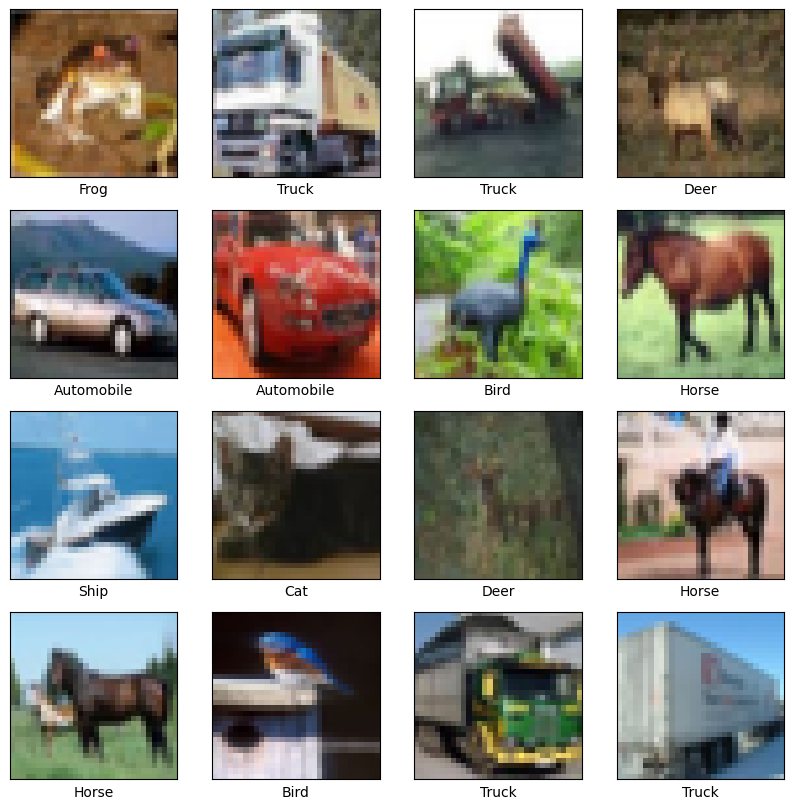

In [5]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

plt.figure(figsize=(10, 10))
for i in range(16):
  plt.subplot(4, 4, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(x_train[i], vmin=0, vmax=1)
  plt.xlabel(class_names[np.argmax(y_train[i])])

plt.show()

In [6]:
model = tf.keras.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding= 'same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(64, (3, 3), activation='relu', padding= 'same'))
model.add((layers.Conv2D(64, (3, 3), activation='relu', padding= 'same')))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))


model.add(layers.Conv2D(128, (3,3), activation='relu', padding= 'same'))
model.add(layers.Conv2D(128, (3,3), activation='relu', padding= 'same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#compiling the model
model.compile(
    optimizer= 'adam',
    loss= 'categorical_crossentropy',
    metrics= ['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 882,474 (3.37 MB)

 Trainable params: 882,474 (3.37 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#fitting model
history = model.fit(x_train, y_train,
                    epochs=40,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3417 - loss: 1.7576 - val_accuracy: 0.4580 - val_loss: 1.4549
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5171 - loss: 1.3311 - val_accuracy: 0.5929 - val_loss: 1.1404
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5915 - loss: 1.1444 - val_accuracy: 0.6163 - val_loss: 1.1324
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6425 - loss: 1.0142 - val_accuracy: 0.6911 - val_loss: 0.8744
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6718 - loss: 0.9336 - val_accuracy: 0.7082 - val_loss: 0.8229
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6997 - loss: 0.8629 - val_accuracy: 0.7258 - val_loss: 0.7871
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7134 - loss: 0.8217 - val_accuracy: 0.7352 - val_loss: 0.7618
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7289 - loss: 0.7709 - val_accuracy: 

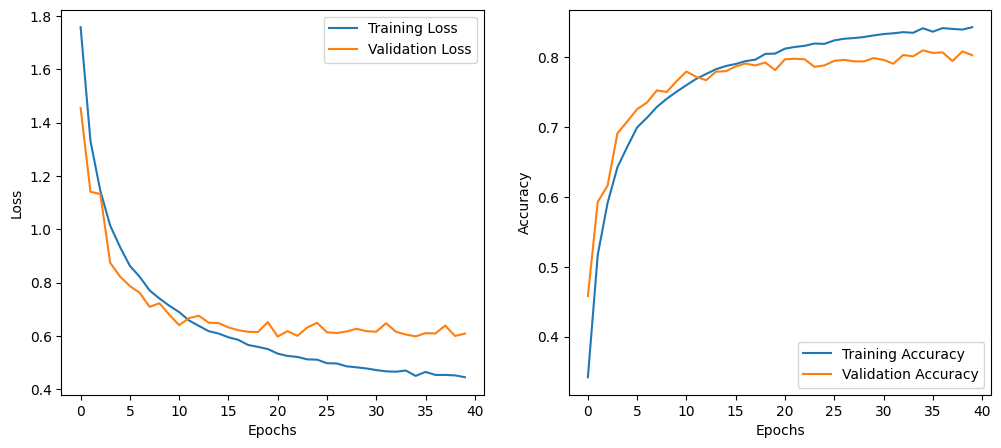

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


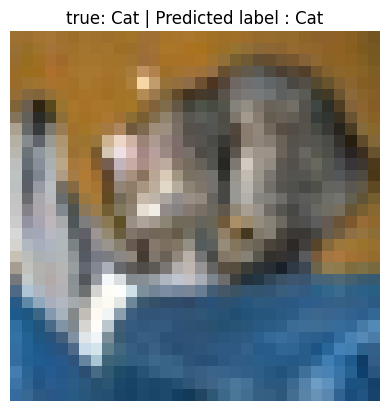

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


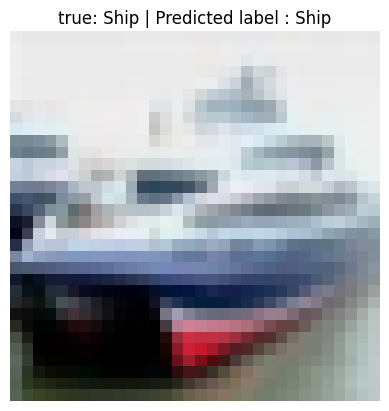

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


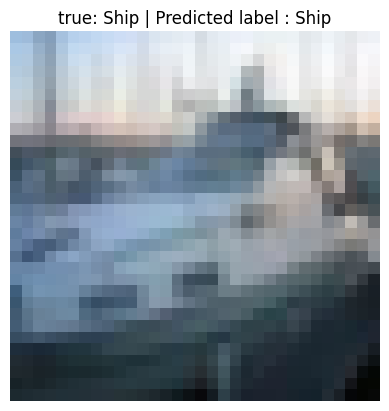

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


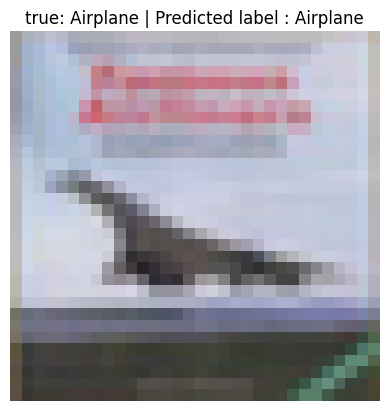

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


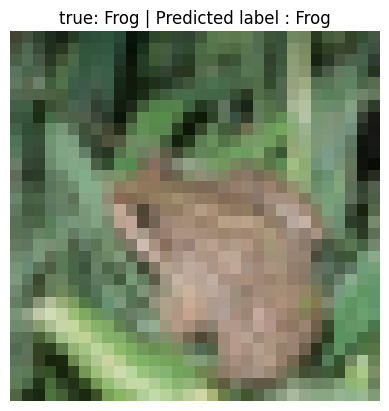

In [10]:
def plot_predictions(index):
  img = x_test[index]
  true_label = class_names[np.argmax(y_test[index])]
  pred_probs = model.predict(np.expand_dims(img, axis=0))
  predicted_label = class_names[np.argmax(pred_probs)]

  plt.imshow(img)
  plt.title(f"true: {true_label} | Predicted label : {predicted_label}")
  plt.axis('off')
  plt.show()


for i in range(5):
  plot_predictions(i)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted label for the unknown image: Truck


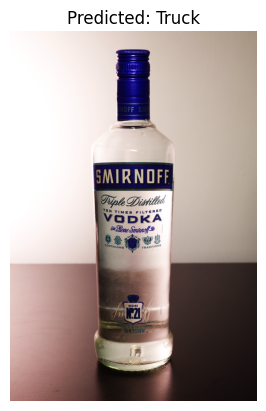

In [20]:
#predicting on a random image outside the test set
import cv2

img_unk = cv2.imread('/content/test_img.jpg')
plt.imshow(img_unk)

#preprocessing the image
img_unk = cv2.resize(img_unk, (32, 32))
img_unk = img_unk.astype('float32') / 255.0

# Expand dimensions to match model input shape (add batch dimension)
img_unk_processed = np.expand_dims(img_unk, axis=0)

# Get predictions
pred_probs = model.predict(img_unk_processed)
predicted_label_index = np.argmax(pred_probs)
predicted_label = class_names[predicted_label_index]

print(f"Predicted label for the unknown image: {predicted_label}")
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [21]:
print("Prediction Probabilities:")
for i, prob in enumerate(pred_probs[0]):
    print(f"{class_names[i]}: {prob:.4f}")

Prediction Probabilities:
Airplane: 0.0002
Automobile: 0.0007
Bird: 0.0000
Cat: 0.0068
Deer: 0.0000
Dog: 0.0025
Frog: 0.0000
Horse: 0.0010
Ship: 0.1902
Truck: 0.7986
